<a href="https://colab.research.google.com/github/r-okotie179/charity-idea/blob/main/youth_matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I am redoing the youth model in a more structured way.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [3]:
topic_list = ['art', 'running', 'piano', 'basketball', 'linguistics', 'french', 'maths', 'physics', 'robotics', 'product design', 'fashion design', 'tutoring', 'academic extension']

In [4]:
# student attributes: location, topics, strength of interest, budget limit
def random_location():
    return (np.random.uniform(-55,-54), np.random.uniform(1,3))

def topic_selection():
    '''
    The area for improvement here will focus on parsing info of topics from surveys and being able to cluster topics to provide useful predictions. Here, there is a discrete (and not really overlapping) distribution of topics.
    '''
    n = np.random.randint(1, 7)
    topic_list = ['art', 'running', 'piano', 'basketball', 'linguistics', 'french', 'maths', 'physics', 'robotics', 'product design', 'fashion design', 'tutoring', 'academic extension']
    loop=[]
    for int in range(n):
        u = np.random.randint(0, len(topic_list))
        loop.append(topic_list[u])
    chosen_topics = list(set(loop))
    interest_weighting = [np.random.randint(1,11) for i in range(len(chosen_topics))]

    topic_vector = list(zip(chosen_topics, interest_weighting))
    return topic_vector

def student_budget_limit():
    '''
    Will follow a normal distribution of mean 0 and sd pretty small where the input is the x-value of the function and the output is the y-value of the function (the plot will be scaled such that the maximum budget a student can have is around 20/25 pounds)
    '''
    budget = round(np.abs(np.random.normal(loc=0, scale=1)))
    return budget

def student_graph(num):
    G = nx.Graph()
    for stud in range(num):
        pos = random_location()
        topic_vector = topic_selection()
        budget_limit = student_budget_limit()
        G.add_node(stud, pos=pos, topics=topic_vector, budget=budget_limit)
    return G


In [9]:
G = student_graph(4)

In [4]:
p = (nx.get_node_attributes(G, 'pos'))
print(len(p))

4


Here are notes for future improvments for each of these points:

*Location*: Since I could be aggragating info based off of attended school, there would need to be a radius (and probability distribution) of uncertainty to map out where students could be travelling. The focus here would be to make decisions under the uncertainty of not knowing the practical travel limitations, whilst respecting the anonymity of the pupils.

*Topics*: People's interests cannot be broken down into single words **and** they are subject to change. Some mechanism to be able to match how a given person's interest is submitted to the given description of a club would be useful for good results.

A later recommendation system is another challenge: clustering based on profiles who are similar? How can new things be suggested, present things that are distinctedly outside of clusters?

*Budget Limit*: The distance (or rather travel time and associated cost), should factor into this budget limit and could help suggest diferent events that would allow more connveniece to youth participation.



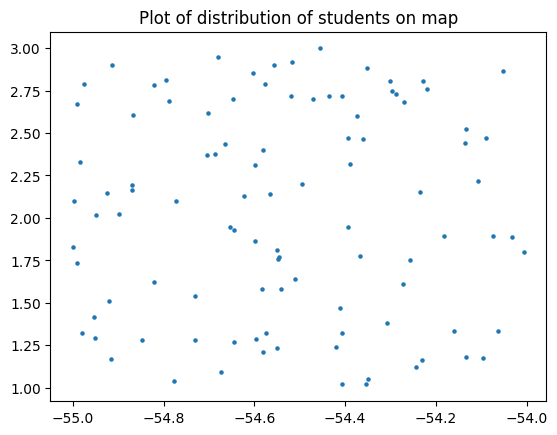

In [10]:
P = student_graph(100)

loc_attr = nx.get_node_attributes(P, 'pos')
lat = [loc_attr[idx][0] for idx in range(len(loc_attr))]
log = [loc_attr[idx][1] for idx in range(len(loc_attr))]
plt.scatter(lat, log, s=5)
plt.title("Plot of distribution of students on map")
plt.show()

I have been trying to cluster the student-student attributes but all my intentions seem to be too complex.

Therefore, I will do some pretty simple tests to get an indicative result and then iterate from there into something that can reliably handle real data and uncertain inputs.

This first approach is to vectorise student attributes into some space, and cluster those vectors which are similar to each other.

Then, from within these groups, I could add an edge based logic (rather than using KNN) to have a graph of similarity between students.

One note: the way in which the vectorisation of nodes works (within a function) should have some returned object that can be general to unpack for the edge logic function.

More clearly:
```
def cluster_logic(graph):
    return nested_list # the nested lists being the identifier of nodes (e.g. [1,5,66,199])

def edge_weight(cluster_list):
    return edge_weight_list # [[node, comp_node, weight], ...]

# update graph structure by adding the edges
```

In [5]:
def vectorise_topics(topic_vector, topic_list):
    vec = np.zeros(len(topic_list))
    for topic, weight in topic_vector:
        vec[topic_list.index(topic)] = weight
    return vec

In [7]:
n = 50
Q = student_graph(n)

def vectored_list(graph):
    vect_list = []
    for i in range(n):
        v = vectorise_topics(graph.nodes[i]["topics"], topic_list)
        vect_list.append(v)
    return vect_list

[array([ 0.,  3.,  8.,  0.,  0.,  0.,  0.,  8.,  0.,  0.,  0.,  0., 10.]), array([0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 6., 0., 4., 9., 0., 6., 0., 0., 0., 0., 6., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 8., 2.]), array([0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0.]), array([1., 0., 0., 0., 3., 0., 0., 7., 0., 0., 0., 0., 0.]), array([6., 9., 0., 0., 0., 8., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 1.]), array([ 0.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,  3., 10.,  0.,  0.,  0.]), array([0., 0., 0., 0., 0., 7., 0., 0., 0., 0., 5., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 4., 0., 5., 0.]), array([10.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.]), array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1., 5., 4., 0., 0., 0., 5., 0., 0., 0.

Now there is a list of attributes in vector form, I will work through a rudimentary way to cluster the points just to see the full stack working.

There is one idea (that is wholly inefficient) but would be cool to work on.